In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

In [3]:
data = pd.read_csv('./dataset/PurchasesFINAL12312016.csv')
data.head()

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2015-12-21,2016-01-02,2016-01-04,2016-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-02,2016-01-07,2016-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2015-12-24,2016-01-02,2016-01-09,2016-02-16,21.32,5,106.60,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype  
---  ------          -----  
 0   InventoryId     object 
 1   Store           int64  
 2   Brand           int64  
 3   Description     object 
 4   Size            object 
 5   VendorNumber    int64  
 6   VendorName      object 
 7   PONumber        int64  
 8   PODate          object 
 9   ReceivingDate   object 
 10  InvoiceDate     object 
 11  PayDate         object 
 12  PurchasePrice   float64
 13  Quantity        int64  
 14  Dollars         float64
 15  Classification  int64  
dtypes: float64(2), int64(6), object(8)
memory usage: 289.6+ MB


In [5]:
df = data.copy()

In [6]:
pd.to_datetime(df['PODate'])

0         2015-12-21
1         2015-12-22
2         2015-12-22
3         2015-12-22
4         2015-12-24
             ...    
2372469   2016-12-19
2372470   2016-12-19
2372471   2016-12-19
2372472   2016-12-19
2372473   2016-12-19
Name: PODate, Length: 2372474, dtype: datetime64[ns]

In [7]:
date_col = ['PODate', 'ReceivingDate', 'InvoiceDate','PayDate']
df[date_col] = df[date_col].apply(pd.to_datetime)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype         
---  ------          -----         
 0   InventoryId     object        
 1   Store           int64         
 2   Brand           int64         
 3   Description     object        
 4   Size            object        
 5   VendorNumber    int64         
 6   VendorName      object        
 7   PONumber        int64         
 8   PODate          datetime64[ns]
 9   ReceivingDate   datetime64[ns]
 10  InvoiceDate     datetime64[ns]
 11  PayDate         datetime64[ns]
 12  PurchasePrice   float64       
 13  Quantity        int64         
 14  Dollars         float64       
 15  Classification  int64         
dtypes: datetime64[ns](4), float64(2), int64(6), object(4)
memory usage: 289.6+ MB


In [9]:
str_col = ['Store','Brand','Classification','VendorNumber','PONumber']
df[str_col] = df[str_col].astype(str)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype         
---  ------          -----         
 0   InventoryId     object        
 1   Store           object        
 2   Brand           object        
 3   Description     object        
 4   Size            object        
 5   VendorNumber    object        
 6   VendorName      object        
 7   PONumber        object        
 8   PODate          datetime64[ns]
 9   ReceivingDate   datetime64[ns]
 10  InvoiceDate     datetime64[ns]
 11  PayDate         datetime64[ns]
 12  PurchasePrice   float64       
 13  Quantity        int64         
 14  Dollars         float64       
 15  Classification  object        
dtypes: datetime64[ns](4), float64(2), int64(1), object(9)
memory usage: 289.6+ MB


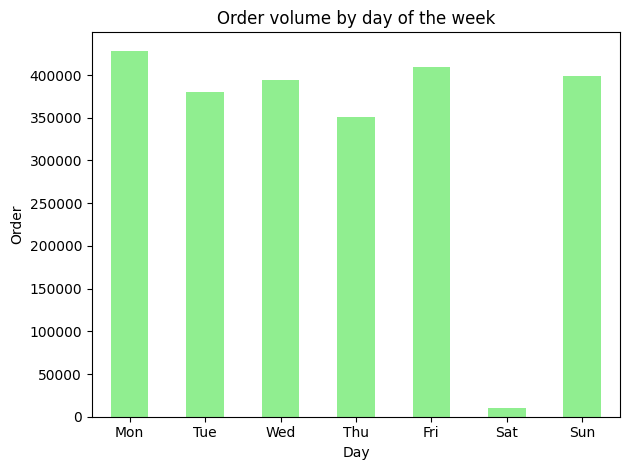

In [15]:
# 요일 추출 (월요일=0, 일요일=6)
df['OrderWeekday'] = df['PODate'].dt.weekday

# 요일별 주문량을 시각화
df['OrderWeekday'].value_counts().sort_index().plot(kind='bar', color='lightgreen')
plt.title('Order volume by day of the week')
plt.xlabel('Day')
plt.ylabel('Order')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.tight_layout()
plt.show()


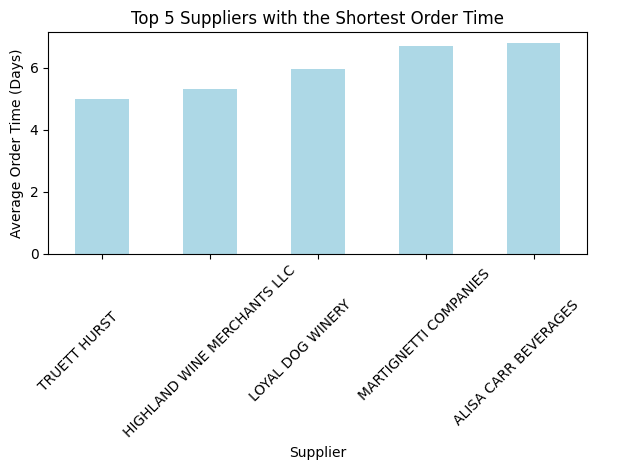

In [16]:
# 분류별 평균 오더 타임 계산
# PODate와 ReceivingDate를 datetime 형식으로 변환
df['PODate'] = pd.to_datetime(df['PODate'])
df['ReceivingDate'] = pd.to_datetime(df['ReceivingDate'])

# OrderTime 계산 (주문일과 수령일 간의 차이)
df['OrderTime'] = (df['ReceivingDate'] - df['PODate']).dt.days

# OrderTime에 결측값이 있는 경우 제거
df = df.dropna(subset=['OrderTime'])


# 주문 시간이 가장 짧은 상위 5개의 공급업체 필터링
fastest_supplier_order_time = df.groupby('VendorName')['OrderTime'].mean().sort_values(ascending=True).head(5)

fastest_supplier_order_time.plot(kind='bar', color='lightblue')
plt.title('Top 5 Suppliers with the Shortest Order Time')
plt.xlabel('Supplier')
plt.ylabel('Average Order Time (Days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





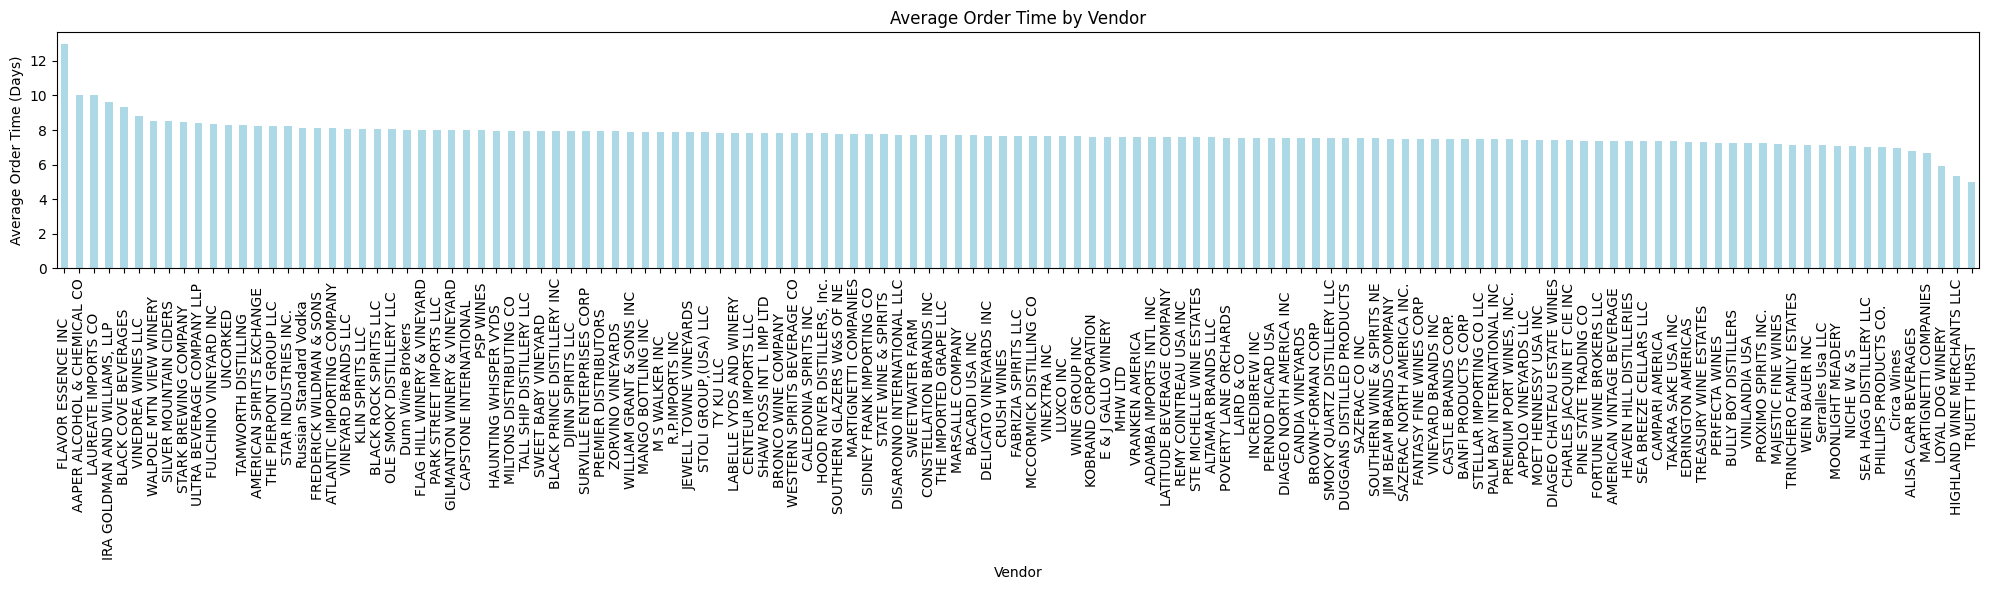

In [18]:
# 주문업체별 평균 OrderTime 계산
vendor_order_time = df.groupby('VendorName')['OrderTime'].mean().sort_values(ascending=False)

# 그래프의 크기를 조정 (가로로 길게 설정)
plt.figure(figsize=(20, 6))  # 가로 15, 세로 6으로 설정

# 시각화
vendor_order_time.plot(kind='bar', color='lightblue')
plt.title('Average Order Time by Vendor')
plt.xlabel('Vendor')
plt.ylabel('Average Order Time (Days)')
plt.xticks(rotation=90)  # Rotate 90 degrees if vendor names are long
plt.tight_layout()
plt.show()